In [21]:
#!pip install tensorflow==2.18.0 tensorflow-gpu==2.18.0 opencv-python matplotlib


In [1]:
import cv2
import os
import random
import numpy as np
from matplotlib import pyplot as plt

In [2]:
#API
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Layer, Conv2D, Dense, MaxPooling2D, Input, Flatten
import tensorflow as tf

In [3]:
#avoid OOM errors by setting GPU Memory Consumtion Growth
gpus= tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [4]:
# Setup paths
POS_PATH = os.path.join('data', 'positive')
NEG_PATH = os.path.join('data', 'negative')
ANC_PATH = os.path.join('data', 'anchor')

In [38]:
# Make the directories
os.makedirs(POS_PATH)
os.makedirs(NEG_PATH)
os.makedirs(ANC_PATH)

FileExistsError: [WinError 183] Cannot create a file when that file already exists: 'data\\positive'

In [11]:
# Uncompress Tar GZ Labelled Faces in the Wild Dataset
!tar -xf lfw.tgz
# http://vis-www.cs.umass.edu/lfw/

^C


In [5]:
# Move LFW Images to the following repository data/negative
for directory in os.listdir('lfw'):
    for file in os.listdir(os.path.join('lfw', directory)):
        EX_PATH = os.path.join('lfw', directory, file)
        NEW_PATH = os.path.join(NEG_PATH, file)
        os.replace(EX_PATH, NEW_PATH)

KeyboardInterrupt: 

In [6]:
import cv2

# Check for available webcam indices
for i in range(10):  # Check indices from 0 to 9
    cap = cv2.VideoCapture(i)
    if cap.isOpened():
        print(f"Webcam found at index {i}")
        cap.release()
    else:
        print(f"No webcam at index {i}")

Webcam found at index 0
No webcam at index 1
No webcam at index 2
No webcam at index 3
No webcam at index 4
No webcam at index 5
No webcam at index 6
No webcam at index 7
No webcam at index 8
No webcam at index 9


In [7]:
# Import uuid library to generate unique image names
import uuid

In [8]:
os.path.join(ANC_PATH, '{}.jpg'.format(uuid.uuid1()))

'data\\anchor\\e245946a-cb1c-11ef-9ce5-c0180328a67c.jpg'

In [9]:
# Establish a connection to the webcam
cap = cv2.VideoCapture(0)
while cap.isOpened(): 
    ret, frame = cap.read()
   
    # Cut down frame to 250x250px
    frame = frame[120:120+250,200:200+250, :]
    
    # Collect anchors 
    if cv2.waitKey(1) & 0XFF == ord('a'):
        # Create the unique file path 
        imgname = os.path.join(ANC_PATH, '{}.jpg'.format(uuid.uuid1()))
        # Write out anchor image
        cv2.imwrite(imgname, frame)
    
    # Collect positives
    if cv2.waitKey(1) & 0XFF == ord('p'):
        # Create the unique file path 
        imgname = os.path.join(POS_PATH, '{}.jpg'.format(uuid.uuid1()))
        # Write out positive image
        cv2.imwrite(imgname, frame)
    
    # Show image back to screen
    cv2.imshow('Image Collection', frame)
    
    # Breaking gracefully
    if cv2.waitKey(1) & 0XFF == ord('q'):
        break
        
# Release the webcam
cap.release()
# Close the image show frame
cv2.destroyAllWindows()

In [10]:
anchor = tf.data.Dataset.list_files(ANC_PATH+'\*.jpg').take(50)
positive = tf.data.Dataset.list_files(POS_PATH+'\*.jpg').take(100)
negative = tf.data.Dataset.list_files(NEG_PATH+'\*.jpg').take(300)

<>:1: SyntaxWarning: invalid escape sequence '\*'
<>:2: SyntaxWarning: invalid escape sequence '\*'
<>:3: SyntaxWarning: invalid escape sequence '\*'
<>:1: SyntaxWarning: invalid escape sequence '\*'
<>:2: SyntaxWarning: invalid escape sequence '\*'
<>:3: SyntaxWarning: invalid escape sequence '\*'
C:\Users\Snow\AppData\Local\Temp\ipykernel_2492\729151919.py:1: SyntaxWarning: invalid escape sequence '\*'
  anchor = tf.data.Dataset.list_files(ANC_PATH+'\*.jpg').take(50)
C:\Users\Snow\AppData\Local\Temp\ipykernel_2492\729151919.py:2: SyntaxWarning: invalid escape sequence '\*'
  positive = tf.data.Dataset.list_files(POS_PATH+'\*.jpg').take(100)
C:\Users\Snow\AppData\Local\Temp\ipykernel_2492\729151919.py:3: SyntaxWarning: invalid escape sequence '\*'
  negative = tf.data.Dataset.list_files(NEG_PATH+'\*.jpg').take(300)


In [11]:
dir_test = anchor.as_numpy_iterator()

In [12]:
print(dir_test.next())

b'data\\anchor\\f3930e0d-c725-11ef-8ffa-c0180328a67c.jpg'


In [13]:
def preprocess(file_path):
    
    # Read in image from file path
    byte_img = tf.io.read_file(file_path)
    # Load in the image 
    img = tf.io.decode_jpeg(byte_img)
    
    # Preprocessing steps - resizing the image to be 100x100x3
    img = tf.image.resize(img, (100,100))
    # Scale image to be between 0 and 1 
    img = img / 255.0
    
    # Return image
    return img

In [14]:
img = preprocess('data\\anchor\\f5fc0e41-c725-11ef-b565-c0180328a67c.jpg')

In [15]:
img.numpy().min()

np.float32(0.0)

In [16]:
img.numpy().max()

np.float32(0.8715686)

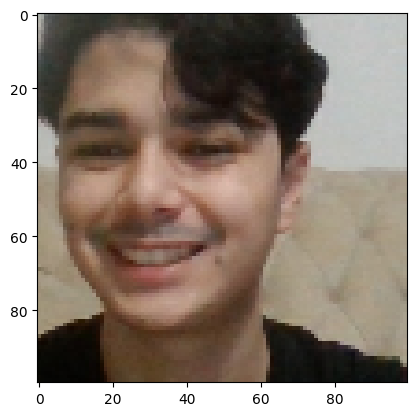

In [17]:
plt.imshow(img)

In [18]:
dataset.map(preprocess)

NameError: name 'dataset' is not defined

In [19]:
# (anchor, positive) --> 1,1,1,1,1
# (anchor, negative) --> 0,0,0,0,0

In [20]:
positives = tf.data.Dataset.zip((anchor, positive, tf.data.Dataset.from_tensor_slices(tf.ones(len(anchor)))))
negatives = tf.data.Dataset.zip((anchor, negative, tf.data.Dataset.from_tensor_slices(tf.zeros(len(anchor)))))
data = positives.concatenate(negatives)

In [21]:
samples = data.as_numpy_iterator()

In [22]:
exampple = samples.next()

In [23]:
exampple

(b'data\\anchor\\f5fc0e41-c725-11ef-b565-c0180328a67c.jpg',
 b'data\\positive\\43b4e9d3-c726-11ef-9b5f-c0180328a67c.jpg',
 np.float32(1.0))

In [24]:
def preprocess_twin(input_img, validation_img, label):
    return(preprocess(input_img), preprocess(validation_img), label)

In [25]:
res = preprocess_twin(*exampple)

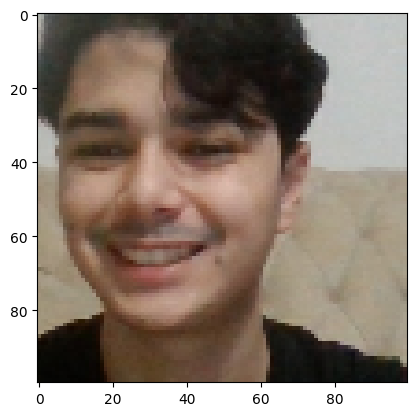

In [26]:
plt.imshow(res[0])

In [27]:
res[0]

<tf.Tensor: shape=(100, 100, 3), dtype=float32, numpy=
array([[[0.6838235 , 0.70343137, 0.67990196],
        [0.6333333 , 0.65294117, 0.6313726 ],
        [0.41029412, 0.4269608 , 0.42009804],
        ...,
        [0.7595588 , 0.76740193, 0.7556372 ],
        [0.75710785, 0.764951  , 0.7531863 ],
        [0.75490195, 0.7627451 , 0.7509804 ]],

       [[0.6906863 , 0.7004902 , 0.67401963],
        [0.6370098 , 0.64485294, 0.6272059 ],
        [0.36568627, 0.38014707, 0.3735294 ],
        ...,
        [0.7617647 , 0.77156866, 0.7676471 ],
        [0.75661767, 0.76642156, 0.7625    ],
        [0.7558824 , 0.7656863 , 0.7617647 ]],

       [[0.6870098 , 0.6879902 , 0.65857846],
        [0.58112746, 0.58504903, 0.5625    ],
        [0.375     , 0.37769607, 0.36813724],
        ...,
        [0.7534314 , 0.7735294 , 0.76740193],
        [0.7529412 , 0.76862746, 0.7647059 ],
        [0.75686276, 0.77254903, 0.76862746]],

       ...,

       [[0.0245098 , 0.02647059, 0.00784314],
        [0.02

In [28]:
# Build dataloader pipeline
data = data.map(preprocess_twin)
data = data.cache()
data = data.shuffle(buffer_size=1024)

In [29]:
samples = data.as_numpy_iterator()

In [30]:
samp = samples.next()

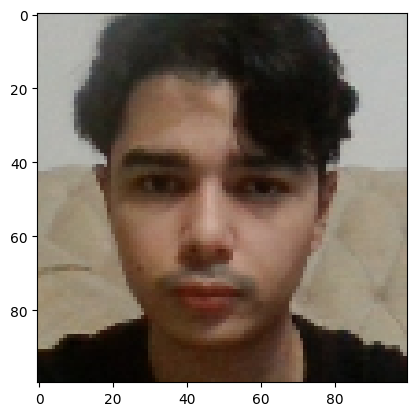

In [31]:
plt.imshow(samp[0])

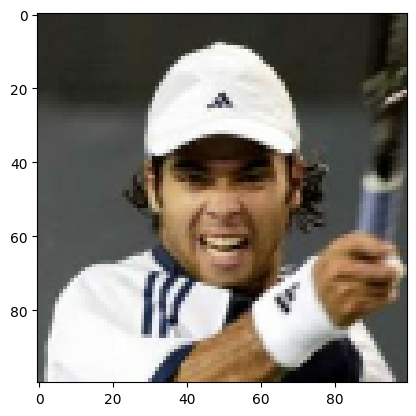

In [32]:
plt.imshow(samp[1])

In [33]:
samp[2]

np.float32(0.0)

In [34]:
# Training partition
train_data = data.take(round(len(data)*.7))
train_data = train_data.batch(16)
train_data = train_data.prefetch(8)

In [35]:
# Testing partition
test_data = data.skip(round(len(data)*.7))
test_data = test_data.take(round(len(data)*.3))
test_data = test_data.batch(16)
test_data = test_data.prefetch(8)

In [36]:
data

<_ShuffleDataset element_spec=(TensorSpec(shape=(100, 100, None), dtype=tf.float32, name=None), TensorSpec(shape=(100, 100, None), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.float32, name=None))>

In [37]:
train_samples = train_data.as_numpy_iterator()

In [38]:
train_sample = train_samples.next()

In [39]:
len(train_sample[0])

16

In [40]:
inp = Input(shape=(100,100,3), name='input_image')

In [41]:
c1 = Conv2D(64, (10,10), activation='relu')(inp)

In [42]:
m1 = MaxPooling2D(64, (2,2), padding='same')(c1)

In [43]:
c2 = Conv2D(128, (7,7), activation='relu')(m1)
m2 = MaxPooling2D(64, (2,2), padding='same')(c2)

In [44]:
c3 = Conv2D(128, (4,4), activation='relu')(m2)
m3 = MaxPooling2D(64, (2,2), padding='same')(c3)

In [45]:
c4 = Conv2D(256, (4,4), activation='relu')(m3)
f1 = Flatten()(c4)
d1 = Dense(4096, activation='sigmoid')(f1)

In [46]:
mod = Model(inputs=[inp], outputs=[d1], name='embedding')

In [47]:
mod.summary()

Model: "embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)             │ (None, 100, 100, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 91, 91, 64)          │          19,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 46, 46, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 40, 40, 128)         │         401,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 20, 20, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 17, 17, 128)         │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 9, 9, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 6, 6, 256)           │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 9216)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 4096)                │      37,752,832 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 38,960,448 (148.62 MB)

 Trainable params: 38,960,448 (148.62 MB)

 Non-trainable params: 0 (0.00 B)

In [48]:
def make_embedding(): 
    inp = Input(shape=(100,100,3), name='input_image')
    
    # First block
    c1 = Conv2D(64, (10,10), activation='relu')(inp)
    m1 = MaxPooling2D(64, (2,2), padding='same')(c1)
    
    # Second block
    c2 = Conv2D(128, (7,7), activation='relu')(m1)
    m2 = MaxPooling2D(64, (2,2), padding='same')(c2)
    
    # Third block 
    c3 = Conv2D(128, (4,4), activation='relu')(m2)
    m3 = MaxPooling2D(64, (2,2), padding='same')(c3)
    
    # Final embedding block
    c4 = Conv2D(256, (4,4), activation='relu')(m3)
    f1 = Flatten()(c4)
    d1 = Dense(4096, activation='sigmoid')(f1)
    
    
    return Model(inputs=[inp], outputs=[d1], name='embedding')

In [49]:
embedding = make_embedding()

In [50]:
embedding.summary()

Model: "embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)             │ (None, 100, 100, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 91, 91, 64)          │          19,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 46, 46, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 40, 40, 128)         │         401,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 20, 20, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 17, 17, 128)         │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 9, 9, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 6, 6, 256)           │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 9216)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4096)                │      37,752,832 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 38,960,448 (148.62 MB)

 Trainable params: 38,960,448 (148.62 MB)

 Non-trainable params: 0 (0.00 B)

In [51]:
class L1Dist(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, input_embedding, validation_embedding):
        # Ensure both inputs have the same shape
        input_embedding = tf.convert_to_tensor(input_embedding)
        validation_embedding = tf.convert_to_tensor(validation_embedding)
        
        # Compute absolute difference and ensure proper shape
        return tf.reduce_mean(tf.math.abs(input_embedding - validation_embedding), axis=0)


In [52]:
l1 = L1Dist()

In [53]:
l1(anchor_embedding, validation_embedding)

NameError: name 'anchor_embedding' is not defined

In [54]:
input_image = Input(name='input_img', shape=(100,100,3))
validation_image = Input(name='validation_img', shape=(100,100,3))

In [55]:
inp_embedding = embedding(input_image)
val_embedding = embedding(validation_image)

In [56]:
siamese_layer = L1Dist()

In [57]:
distances = siamese_layer(inp_embedding, val_embedding)

In [58]:
classifier = Dense(1, activation='sigmoid')(distances)

In [59]:
classifier

<KerasTensor shape=(None, 1), dtype=float32, sparse=False, name=keras_tensor_21>

In [60]:
siamese_network = Model(inputs=[input_image, validation_image], outputs=classifier, name='SiameseNetwork')

In [61]:
siamese_network.summary()

Model: "SiameseNetwork"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_img (InputLayer)        │ (None, 100, 100, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ validation_img (InputLayer)   │ (None, 100, 100, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Functional)        │ (None, 4096)              │      38,960,448 │ input_img[0][0],           │
│                               │                           │                 │ validation_img[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ l1_dist_1 (L1Dist)            │ (None, 4096)              │               0 │ embedding[0][0],           │
│                               │                           │                 │ embedding[1][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 1)                 │           4,097 │ l1_dist_1[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 38,964,545 (148.64 MB)

 Trainable params: 38,964,545 (148.64 MB)

 Non-trainable params: 0 (0.00 B)

In [62]:
def make_siamese_model():
    #Anchor image input in the network
    input_image = Input(name='input_img', shape=(100,100,3))
    #validation image in the network 
    validation_image = Input(name='validation_img', shape=(100,100,3))

    #combine siamese distance components
    siamese_layer = L1Dist()
    siamese_layer._name = 'distance'
    distances = siamese_layer(embedding(input_image), embedding(validation_image))

    #classification Layer 
    classifier = Dense(1, activation='sigmoid')(distances)
    return Model(inputs=[input_image, validation_image], outputs=classifier, name='SiameseNetwork') 

In [63]:
siamese_model = make_siamese_model()

In [64]:
siamese_model.summary()

Model: "SiameseNetwork"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_img (InputLayer)        │ (None, 100, 100, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ validation_img (InputLayer)   │ (None, 100, 100, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Functional)        │ (None, 4096)              │      38,960,448 │ input_img[0][0],           │
│                               │                           │                 │ validation_img[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ l1_dist_2 (L1Dist)            │ (None, 4096)              │               0 │ embedding[2][0],           │
│                               │                           │                 │ embedding[3][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 1)                 │           4,097 │ l1_dist_2[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 38,964,545 (148.64 MB)

 Trainable params: 38,964,545 (148.64 MB)

 Non-trainable params: 0 (0.00 B)

In [65]:
binary_cross_loss = tf.losses.BinaryCrossentropy()

In [66]:
opt = tf.keras.optimizers.Adam(1e-4) # 0.0001

In [67]:
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, 'ckpt')
checkpoint = tf.train.Checkpoint(opt=opt, siamese_model=siamese_model)

In [68]:
test_batch = train_data.as_numpy_iterator()

In [69]:
batch_1 = test_batch.next()

In [70]:
X = batch_1[:2]

In [71]:
y = batch_1[2]

In [72]:
y

array([1., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 1., 1., 0., 1., 1.],
      dtype=float32)

In [73]:
tf.losses.BinaryCrossentropy??

Init signature:
tf.losses.BinaryCrossentropy(
    from_logits=False,
    label_smoothing=0.0,
    axis=-1,
    reduction='sum_over_batch_size',
    name='binary_crossentropy',
    dtype=None,
)
Source:        
@keras_export("keras.losses.BinaryCrossentropy")
class BinaryCrossentropy(LossFunctionWrapper):
    """Computes the cross-entropy loss between true labels and predicted labels.

    Use this cross-entropy loss for binary (0 or 1) classification applications.
    The loss function requires the following inputs:

    - `y_true` (true label): This is either 0 or 1.
    - `y_pred` (predicted value): This is the model's prediction, i.e, a single
        floating-point value which either represents a
        [logit](https://en.wikipedia.org/wiki/Logit), (i.e, value in [-inf, inf]
        when `from_logits=True`) or a probability (i.e, value in [0., 1.] when
        `from_logits=False`).

    Args:
        from_logits: Whether to interpret `y_pred` as a tensor of
            [logit](htt

In [74]:
@tf.function
def train_step(batch):
    
    # Record all of our operations 
    with tf.GradientTape() as tape:     
        # Get anchor and positive/negative image
        X = batch[:2]
        # Get label
        y = batch[2]
        
        # Forward pass
        yhat = siamese_model(X, training=True)
        yhat = tf.squeeze(yhat, axis=-1)
        # Calculate loss
        loss = binary_cross_loss(y, yhat)
    print(loss)

    # Calculate gradients
    grad = tape.gradient(loss, siamese_model.trainable_variables)
    
    # Calculate updated weights and apply to siamese model
    opt.apply_gradients(zip(grad, siamese_model.trainable_variables))
    
    # Return loss
    return loss

In [75]:
def train(data, EPOCHS):
    # Loop through epochs
    for epoch in range(1, EPOCHS+1):
        print('\n Epoch {}/{}'.format(epoch, EPOCHS))
        progbar = tf.keras.utils.Progbar(len(data))
        
        # Loop through each batch
        for idx, batch in enumerate(data):
            # Run train step here
            train_step(batch)
            progbar.update(idx+1)
        
        # Save checkpoints
        if epoch % 10 == 0: 
            checkpoint.save(file_prefix=checkpoint_prefix)

In [76]:
EPOCHS = 50

In [88]:
train(train_data, EPOCHS)


 Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step

 Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step

 Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step

 Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step

 Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step

 Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step

 Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step

 Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step

 Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step

 Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step

 Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step

 Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step

 Epoch 13/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step

 Epoch 14/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step

 Epoch 15/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step

 Epoch 16/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step

 Epoch 17/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step

 Epoch 18/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step

 Epoch 19/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step

 Epoch 20/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step

 Epoch 2

In [90]:
# Import metric calculations
from tensorflow.keras.metrics import Precision, Recall

In [91]:
# Get a batch of test data
test_input, test_val, y_true = test_data.as_numpy_iterator().next()

In [92]:
# Make predictions
y_hat = siamese_model.predict([test_input, test_val])
y_hat

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 634ms/step


array([[8.9704145e-07],
       [4.5913715e-05],
       [9.9926490e-01],
       [9.9979472e-01],
       [1.0000000e+00],
       [9.9979448e-01],
       [1.0000000e+00],
       [7.2838866e-06],
       [4.8080398e-07],
       [9.9999487e-01],
       [1.3794150e-06],
       [9.9995118e-01],
       [2.9043363e-06],
       [1.0045382e-08],
       [9.9994111e-01],
       [9.9978161e-01]], dtype=float32)

In [93]:
# Post processing the results 
[1 if prediction > 0.5 else 0 for prediction in y_hat ]

[0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1]

In [94]:
y_true

array([0., 0., 1., 1., 1., 1., 1., 0., 0., 1., 0., 1., 0., 0., 1., 1.],
      dtype=float32)

In [95]:
# Creating a metric object 
m = Recall()

# Calculating the recall value 
m.update_state(y_true, y_hat)

# Return Recall Result
m.result().numpy()

np.float32(1.0)

In [96]:
# Creating a metric object 
m = Precision()

# Calculating the recall value 
m.update_state(y_true, y_hat)

# Return Recall Result
m.result().numpy()

np.float32(1.0)

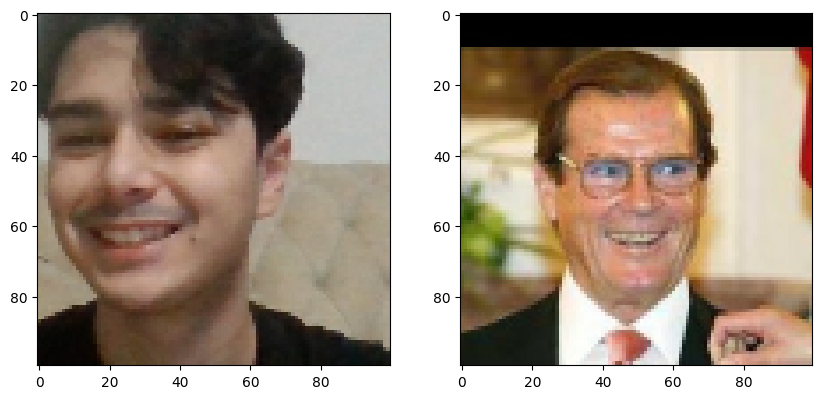

In [97]:
# Set plot size 
plt.figure(figsize=(10,8))

# Set first subplot
plt.subplot(1,2,1)
plt.imshow(test_input[0])

# Set second subplot
plt.subplot(1,2,2)
plt.imshow(test_val[0])

# Renders cleanly
plt.show()

In [98]:
# Save weights
siamese_model.save('siamesemodel.h5')

In [99]:
L1Dist

__main__.L1Dist

In [100]:
# Reload model 
model = tf.keras.models.load_model('siamesemodel.h5', 
                                   custom_objects={'L1Dist':L1Dist, 'BinaryCrossentropy':tf.losses.BinaryCrossentropy})


In [101]:
# Make predictions with reloaded model
model.predict([test_input, test_val])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 762ms/step


array([[8.9704145e-07],
       [4.5913715e-05],
       [9.9926490e-01],
       [9.9979472e-01],
       [1.0000000e+00],
       [9.9979448e-01],
       [1.0000000e+00],
       [7.2838866e-06],
       [4.8080398e-07],
       [9.9999487e-01],
       [1.3794150e-06],
       [9.9995118e-01],
       [2.9043363e-06],
       [1.0045382e-08],
       [9.9994111e-01],
       [9.9978161e-01]], dtype=float32)

In [102]:
# View model summary
model.summary()

Model: "SiameseNetwork"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_img (InputLayer)        │ (None, 100, 100, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ validation_img (InputLayer)   │ (None, 100, 100, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Functional)        │ (None, 4096)              │      38,960,448 │ input_img[0][0],           │
│                               │                           │                 │ validation_img[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ l1_dist_2 (L1Dist)            │ (None, 4096)              │               0 │ embedding[0][0],           │
│                               │                           │                 │ embedding[1][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 1)                 │           4,097 │ l1_dist_2[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 38,964,545 (148.64 MB)

 Trainable params: 38,964,545 (148.64 MB)

 Non-trainable params: 0 (0.00 B)

In [103]:
application_data\verification_images

SyntaxError: unexpected character after line continuation character (2818603333.py, line 1)

In [104]:
os.listdir(os.path.join('application_data', 'verification_images'))

['00496718-c726-11ef-a375-c0180328a67c.jpg',
 '032d314b-c726-11ef-8d2f-c0180328a67c.jpg',
 '03805ab6-c726-11ef-9230-c0180328a67c.jpg',
 '0483ce0d-c726-11ef-a8a4-c0180328a67c.jpg',
 '04a3c475-c726-11ef-a838-c0180328a67c.jpg',
 '05798c89-c726-11ef-a41e-c0180328a67c.jpg',
 '06657280-c726-11ef-8e6d-c0180328a67c.jpg',
 '06af4170-c726-11ef-b53a-c0180328a67c.jpg',
 '06e0cac2-c726-11ef-8f18-c0180328a67c.jpg',
 '076d0b22-c726-11ef-abfc-c0180328a67c.jpg',
 '0790a468-c726-11ef-b214-c0180328a67c.jpg',
 '08098a1b-c726-11ef-9cc8-c0180328a67c.jpg',
 '082dd68a-c726-11ef-bf29-c0180328a67c.jpg',
 '084b3ce3-c726-11ef-839d-c0180328a67c.jpg',
 '1a7bd22e-c726-11ef-8cc2-c0180328a67c.jpg',
 '1ae8e411-c726-11ef-adb4-c0180328a67c.jpg',
 '1b6dce28-c726-11ef-b791-c0180328a67c.jpg',
 '1bcee6ed-c726-11ef-89c2-c0180328a67c.jpg',
 '1c6fc891-c726-11ef-b007-c0180328a67c.jpg',
 '1cefbdbc-c726-11ef-8db9-c0180328a67c.jpg',
 '1e48b4da-c726-11ef-8419-c0180328a67c.jpg',
 '21315b36-c726-11ef-8d46-c0180328a67c.jpg',
 '21ef6c23

In [105]:
os.path.join('application_data', 'input_image', 'input_image.jpg')

'application_data\\input_image\\input_image.jpg'

In [106]:
'application_data\\input_image\\input_image.jpg'

'application_data\\input_image\\input_image.jpg'

In [107]:
for image in os.listdir(os.path.join('application_data', 'verification_images')):
    validation_img = os.path.join('application_data', 'verification_images', image)
    print(validation_img)

application_data\verification_images\00496718-c726-11ef-a375-c0180328a67c.jpg
application_data\verification_images\032d314b-c726-11ef-8d2f-c0180328a67c.jpg
application_data\verification_images\03805ab6-c726-11ef-9230-c0180328a67c.jpg
application_data\verification_images\0483ce0d-c726-11ef-a8a4-c0180328a67c.jpg
application_data\verification_images\04a3c475-c726-11ef-a838-c0180328a67c.jpg
application_data\verification_images\05798c89-c726-11ef-a41e-c0180328a67c.jpg
application_data\verification_images\06657280-c726-11ef-8e6d-c0180328a67c.jpg
application_data\verification_images\06af4170-c726-11ef-b53a-c0180328a67c.jpg
application_data\verification_images\06e0cac2-c726-11ef-8f18-c0180328a67c.jpg
application_data\verification_images\076d0b22-c726-11ef-abfc-c0180328a67c.jpg
application_data\verification_images\0790a468-c726-11ef-b214-c0180328a67c.jpg
application_data\verification_images\08098a1b-c726-11ef-9cc8-c0180328a67c.jpg
application_data\verification_images\082dd68a-c726-11ef-bf29-c01

In [108]:
def verify(model, detection_threshold, verification_threshold):
    # Build results array
    results = []
    for image in os.listdir(os.path.join('application_data', 'verification_images')):
        input_img = preprocess(os.path.join('application_data', 'input_image', 'input_image.jpg'))
        validation_img = preprocess(os.path.join('application_data', 'verification_images', image))
        
        # Make Predictions 
        result = model.predict(list(np.expand_dims([input_img, validation_img], axis=1)))
        results.append(result)
    
    # Detection Threshold: Metric above which a prediciton is considered positive 
    detection = np.sum(np.array(results) > detection_threshold)
    
    # Verification Threshold: Proportion of positive predictions / total positive samples 
    verification = detection / len(os.listdir(os.path.join('application_data', 'verification_images'))) 
    verified = verification > verification_threshold
    
    return results, verified

In [109]:
cap = cv2.VideoCapture(0)
while cap.isOpened():
    ret, frame = cap.read()
    frame = frame[120:120+250,200:200+250, :]
    
    cv2.imshow('Verification', frame)
    
    # Verification trigger
    if cv2.waitKey(10) & 0xFF == ord('v'):
        # Save input image to application_data/input_image folder 
        cv2.imwrite(os.path.join('application_data', 'input_image', 'input_image.jpg'), frame)
        # Run verification
        results, verified = verify(model, 0.9, 0.7)
        print(verified)
    
    if cv2.waitKey(10) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()